# 25 — Raman tensors: two fields and a displacement

Notebook 19 computed the **dielectric constant** — a second derivative of the energy with
respect to an electric field. Notebook 21 differentiated it once more with respect to a
**strain**. This one differentiates the same object with respect to **where an atom is**,
and gets the **Raman tensor**: `d(eps)/d(tau)`, the quantity a non-resonant Raman
intensity is computed from.

It is the same construction as notebook 21 — one `jvp` of the variational second-order
energy at frozen first-order wavefunctions, which is the 2n+1 theorem — with the atomic
positions as the geometry variable instead of a strain. **Every tangent already existed**:
the displacement response is the one the dynamical matrix of notebook 20 already solves,
the field response is notebook 19's, and the position operator's own derivative is the
extra Sternheimer solve notebook 21 wrote.

Two things make this phase unusual, and they are the reason it is worth five minutes:

* **QE's third derivative of the exchange-correlation energy is a hardcoded
  Perdew-Zunger parameterisation** (`PHonon/PH/d2mxc.f90`), so `ph.x` stops outright on
  `'third order derivatives not implemented with GGA'`. Here that object is never
  written: the kernel is a `jvp` of `v_of_rho`, and differentiating the second-order
  energy a third time differentiates it again. Any functional works.
* **The reference is broken.** The vendored `ph.x` 7.5 does not reproduce its own
  committed example, and fails its own internal consistency check. So the validation is a
  finite difference of `eps` over re-converged displaced cells — which is what the figure
  below shows.

Headline: **-3.118279** against a finite difference's **-3.118310**, 1.0e-5 relative.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

from pypresso import Calculator
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.response.efield import dielectric_tensor
from pypresso.response.electrostriction import refined_states
from pypresso.response.nonlinear import raman_tensors, require_a_complete_third_derivative
from pypresso.scf import Calculation, run_scf
from pypresso.system import build_system

CASES = Path("../tests/data/qe")
PSEUDO = Path("../tests/data/pseudo")

# AlAs, because zincblende has no inversion centre and silicon does -- and because it is
# the system of QE's own Raman example. The k-grid is **unshifted** and run whole under
# `nosym`, which is how this phase shipped: a Raman tensor carries two field labels and an
# atom, so a symmetry-reduced sum is incomplete in all three until the rank-3 average
# (`symtensor3`) completes it. P36 wrote that average -- notebook 26 runs the same case on
# 8 k-points instead of 64 -- and the closed grid is kept here because it is what the
# comparison in section 3 was made against.
alas = Calculator.from_file(CASES / "alas-raman.in", pseudo_dir=PSEUDO,
                            announce=False, conv_thr=1e-12)
system, pseudos = alas.system, alas.pseudos
calculation = alas.calculation
scf = alas.get_scf()

print(f"AlAs   {len(system.kpoints.weights)} k-points, "
      f"total energy {scf.total_energy:.8f} Ry")
print(f"pw.x                            -16.88368446 Ry")

AlAs   64 k-points, total energy -16.88368446 Ry
pw.x                            -16.88368446 Ry


## 1. One call

Inside it: the self-consistent field response (notebook 19), the self-consistent
**displacement** response (notebook 20's, `3 nat` perturbations), one further Sternheimer
solve per mode for the position operator's own derivative, and then `3 nat` `jvp`s of the
second-order energy.

In [2]:
raman = alas.get_raman_tensors()

print(f"epsilon_infinity        {np.trace(raman.epsilon) / 3:.6f}")
print(f"ph.x                    12.967322")
print(f"field response          {len(raman.field.history)} iterations")
print(f"displacement response   {len(raman.phonon_history)} iterations")

epsilon_infinity        12.967421
ph.x                    12.967322
field response          9 iterations
displacement response   10 iterations


## 2. The tensor, and the two things nothing imposed

AlAs is `-43m`. A rank-3 tensor in that point group has exactly one independent component:
the entries with all three indices different, all equal, and everything else zero. The run
is `nosym` on the whole grid and **no average is applied anywhere**, so the zeros are a
measurement of every index convention in the phase at once.

The second check is the **translational sum rule**: moving every atom by the same vector
translates the crystal, which cannot change `eps`, so the tensors sum to zero over atoms.
It is P25's acoustic sum rule one derivative up, and like it, it is reported rather than
imposed.

In [3]:
for atom in range(raman.raman.shape[0]):
    label = system.structure.species[system.structure.types[atom]].name
    block = raman.raman[atom, 0]          # displacement along x
    print(f"  atom {atom} ({label:2s}), displaced along x:")
    for row in block:
        print("      " + "".join(f"{v:12.6f}" for v in row))

scale = np.abs(raman.raman).max()
forbidden = max(abs(raman.raman[a, c, i, j])
                for a in range(raman.raman.shape[0])
                for c in range(3) for i in range(3) for j in range(3)
                if len({c, i, j}) != 3)
print(f"\nlargest entry T_d forbids   {forbidden / scale:.1e} of the scale")
print(f"translational sum rule      {raman.sum_rule_relative:.1e} of the scale")

  atom 0 (Al), displaced along x:
         -0.000000    0.000000    0.000000
          0.000000   -0.000000   -3.118279
          0.000000   -3.118279   -0.000000
  atom 1 (As), displaced along x:
         -0.000000   -0.000000   -0.000000
         -0.000000    0.000000    3.119166
         -0.000000    3.119166   -0.000000

largest entry T_d forbids   1.6e-13 of the scale
translational sum rule      2.8e-04 of the scale


## 3. What the reference does

QE computes the same tensor with `ph.x`'s `lraman = .true.`, by a different route —
Lazzeri and Mauri's *second*-order response to the field, where this is the strictly
first-order 2n+1 contraction. Two independent assemblies of the same number is exactly the
comparison this project is built on.

It could not be made. The vendored `ph.x` **7.5** does not reproduce QE's own committed
example (`PHonon/examples/example05`, generated with v6.0 in 2016), and its own internal
check says so: `dhdrhopsi` obtains the k-derivative of the wavefunctions by finite
differences and prints the dielectric constant they imply beside the analytic one.

In [4]:
rows = [
    ("example05, Raman tensor",        "-0.78497", "-1.86812", "v6.0 / 7.5"),
    ("example05, electro-optic",       "40.4578",  "157.873",  "v6.0 / 7.5"),
    ("example05, eps: analytic",       "8.8147",   "8.8143",   "the two agree"),
    ("example05, eps: its own f.d.",   "8.8116",   "-0.2880",  "they do not"),
]
print(f"{'':32s}{'v6.0 reference':>16s}{'vendored 7.5':>16s}")
for name, old, new, _ in rows:
    print(f"{name:32s}{old:>16s}{new:>16s}")
print("\nTightening eth_rps and eth_ns by four orders moves the last row by 1e-2,")
print("so it is a regression and not a threshold.")

                                  v6.0 reference    vendored 7.5
example05, Raman tensor                 -0.78497        -1.86812
example05, electro-optic                 40.4578         157.873
example05, eps: analytic                  8.8147          8.8143
example05, eps: its own f.d.              8.8116         -0.2880

Tightening eth_rps and eth_ns by four orders moves the last row by 1e-2,
so it is a regression and not a threshold.


## 4. The figure: a third derivative is the slope of a second one

So the reference is built here instead. `eps` is a quantity this code computes from
scratch at any geometry, so displacing one atom and re-converging gives `eps(tau)` — and
the Raman tensor is its slope. The line below is *not* fitted: it is the analytic
derivative, drawn through the point it was computed at.

Five SCF runs, each followed by its own dielectric response.

In [5]:
steps = np.array([-0.04, -0.02, 0.0, 0.02, 0.04])
base = np.asarray(system.structure.positions)

def epsilon_yz_at(shift):
    positions = base.copy()
    positions[0, 0] += shift
    moved = Calculation(system, pseudos).at_positions(jnp.asarray(positions))
    run = run_scf(system, pseudos, calculation=moved, conv_thr=1e-12, max_iterations=200)
    values, states = refined_states(moved, run)
    tensor = dielectric_tensor(moved, states, values, jnp.asarray(run.density),
                               born_charges=False)
    return float(np.asarray(tensor.epsilon)[1, 2])

curve = np.array([epsilon_yz_at(s) for s in steps])
slope = raman.raman[0, 0, 1, 2]
central = (curve[3] - curve[1]) / (steps[3] - steps[1])
print(f"analytic  d(eps_yz)/d(tau_x) = {slope:.6f}")
print(f"central difference (h=0.02)  = {central:.6f}")
print(f"                    relative   {abs(slope - central) / abs(slope):.1e}")

analytic  d(eps_yz)/d(tau_x) = -3.118279
central difference (h=0.02)  = -3.118310
                    relative   1.0e-05


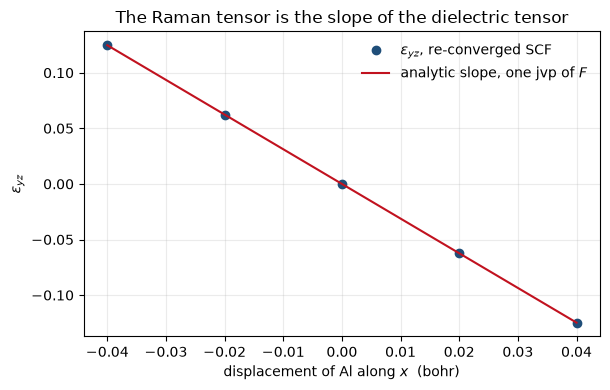

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.plot(steps, curve, "o", color="#1f4e79", label=r"$\epsilon_{yz}$, re-converged SCF")
fine = np.linspace(steps[0], steps[-1], 100)
ax.plot(fine, curve[2] + slope * fine, "-", color="#c1121f",
        label=r"analytic slope, one $\mathrm{jvp}$ of $F$")
ax.set_xlabel(r"displacement of Al along $x$  (bohr)")
ax.set_ylabel(r"$\epsilon_{yz}$")
ax.set_title("The Raman tensor is the slope of the dielectric tensor")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()

## 5. How it works

The whole phase is four lines. `F_ij` is the variational second-order energy of a uniform
field — the functional whose stationary value is `eps` — and the 2n+1 theorem says it may
be differentiated with its first-order wavefunctions held **fixed**:

```python
def epsilon(positions, psi, rho, b):
    moved = calculation.at_positions(positions)
    return 1 - 16 * pi * second_order_energy(moved, psi, rho, b, u) / volume

_, column = jax.jvp(epsilon, (positions, psi, rho, b),
                    (displacement, dpsi, drho, db))
```

The four tangents are: the displacement itself, the response of the states to it, the
response of the density, and the response of the position operator. The first three exist
already — the first is a unit vector, the other two are what the dynamical matrix solves
for. Only `db` is new work, and notebook 21 wrote it.

**`chi^(2)` is refused**, and it is worth seeing why: it is the same functional
differentiated along a third *field*, and the field enters this code only through the
source term. There is no `dH/dE` to differentiate.

In [7]:
try:
    require_a_complete_third_derivative()
except NotImplementedError as error:
    print(str(error))

chi^(2) and the electro-optic tensor are not implemented: the field enters this code only through the source term P_c r|psi> and through the density, so the term of the 2n+1 expression in which the perturbing operator sits between two first-order wavefunctions (<u_i|r_k|u_j>, QE's dvpsi_e2/solve_e2) has nothing to build it from. Its displacement counterpart is computed here and is 42% of the Raman tensor, and no symmetry check catches its absence -- see pypresso.response.nonlinear's module docstring. The Raman tensor, which needs no such term, is raman_tensors()


The size of what is missing is a measurement rather than an estimate, because the
*displacement* derivative has the same term and it is computed here: zeroing it changes
`d(eps_yz)/d(tau)` from **-3.118279** to **-1.809983** — 42% of the answer.

And nothing catches its absence by symmetry. Without that term the field tensor still
vanishes identically in silicon (1.2e-13), still comes out exactly zincblende in AlAs, and
is still symmetric under every permutation of its three labels to 2.5e-13 — because the
omitted term is symmetric too. Kleinman's condition was the check this phase expected to be
decisive, and it is blind here.

---

`PLAN.md` P35 has the derivation, the full validation table and what the missing term
would take. The tests are `tests/regression/test_nonlinear.py`.